<a href="https://colab.research.google.com/github/renegarcialuces/Analisis-de-Datos-Portafolio/blob/main/ED01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Importar herramientas de analisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# **Carga de los datos**

In [96]:

# Cargar documentos para analisis desde la pc
from google.colab import files
uploaded = files.upload()

Saving telecom_users.csv to telecom_users (1).csv


# **Creación del DataFrame**

In [97]:
filename = 'telecom_users.csv'

In [98]:
df = pd.read_csv(filename, index_col=0) #[index_col= 0] Elimina la columna (Unnamed: 0).

# **Conociendo el datset**

In [99]:
# Qué columnas tiene el DataFrame?
df.columns

Index(['IDCliente', 'Genero', 'Aposentado', 'Casado', 'Dependentes',
       'MesesComoCliente', 'ServicoTelefone', 'MultiplasLinhas',
       'ServicoInternet', 'ServicoSegurancaOnline', 'ServicoBackupOnline',
       'ProtecaoEquipamento', 'ServicoSuporteTecnico', 'ServicoStreamingTV',
       'ServicoFilmes', 'TipoContrato', 'FaturaDigital', 'FormaPagamento',
       'ValorMensal', 'TotalGasto', 'Churn', 'Codigo'],
      dtype='object')

In [100]:
# De qué tamaños es el set de datos?
df.shape

(5986, 22)

In [103]:
# Tiene valores nulos o ausentes?
df.isna().sum()

,0
IDCliente,0
Genero,0
Aposentado,0
Casado,0
Dependentes,1
MesesComoCliente,0
ServicoTelefone,0
MultiplasLinhas,0
ServicoInternet,0
ServicoSegurancaOnline,0


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5986 entries, 1869 to 860
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IDCliente               5986 non-null   object 
 1   Genero                  5986 non-null   object 
 2   Aposentado              5986 non-null   int64  
 3   Casado                  5986 non-null   object 
 4   Dependentes             5985 non-null   object 
 5   MesesComoCliente        5986 non-null   int64  
 6   ServicoTelefone         5986 non-null   object 
 7   MultiplasLinhas         5986 non-null   object 
 8   ServicoInternet         5986 non-null   object 
 9   ServicoSegurancaOnline  5986 non-null   object 
 10  ServicoBackupOnline     5986 non-null   object 
 11  ProtecaoEquipamento     5986 non-null   object 
 12  ServicoSuporteTecnico   5986 non-null   object 
 13  ServicoStreamingTV      5986 non-null   object 
 14  ServicoFilmes           5986 non-null   obj

# **Limpieza y preparación de datos**

In [87]:
# Ajuster tipo de categórico a numerico
df['TotalGasto'] = pd.to_numeric(df['TotalGasto'], errors='coerce')

# Covertir columnas numericas a string
df['Aposentado'] = df['Aposentado'].astype('string')

In [88]:
for col in df.columns:
  if df[col].dtypes == 'O':
    df[col] = df[col].astype('string')

In [89]:
# Borrando columnas vacia
df.dropna(axis=1, how='all', inplace=True)

In [90]:
# Borras datos faltantes
df.dropna(how='any', inplace=True)

# **Tablas de frecuencia y gráficos**




***** Genero *****




,Genero,Fca,FcaAda,Fca_%,FcaAda_%
0,Masculino,3043,3043,50.937395,50.937395
1,Feminino,2931,5974,49.062605,100.0


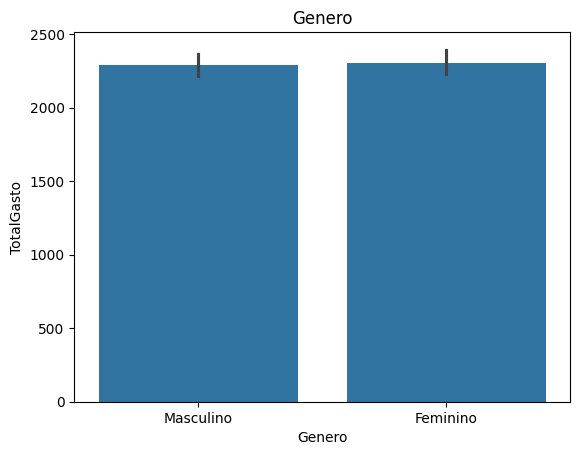




***** Aposentado *****




,Aposentado,Fca,FcaAda,Fca_%,FcaAda_%
0,Não,5008,5008,83.82993,83.82993
1,Sim,966,5974,16.17007,100.0


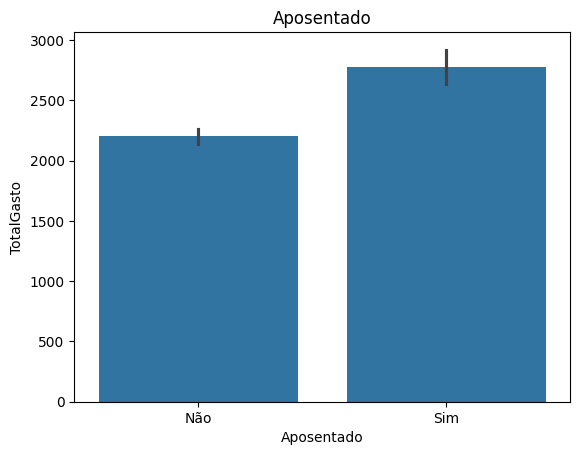




***** Casado *****




,Casado,Fca,FcaAda,Fca_%,FcaAda_%
0,Nao,3080,3080,51.556746,51.556746
1,Sim,2894,5974,48.443254,100.0


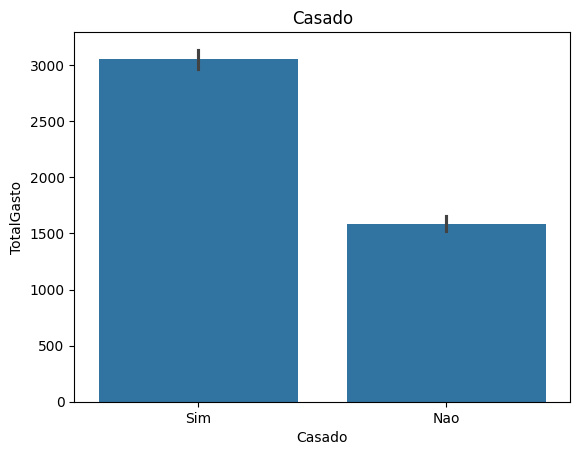




***** Dependentes *****




,Dependentes,Fca,FcaAda,Fca_%,FcaAda_%
0,Nao,4194,4194,70.204218,70.204218
1,Sim,1780,5974,29.795782,100.0


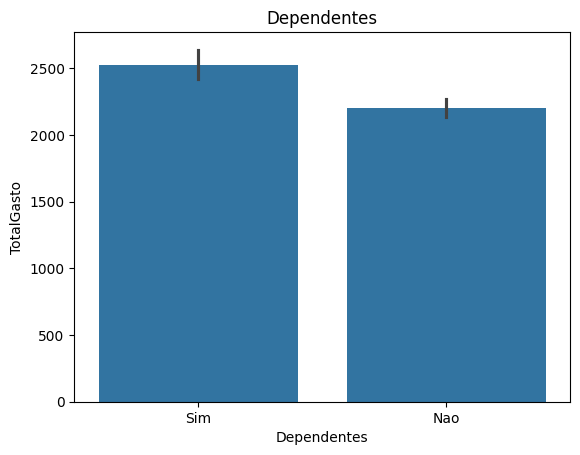




***** ServicoTelefone *****




,ServicoTelefone,Fca,FcaAda,Fca_%,FcaAda_%
0,Sim,5386,5386,90.157349,90.157349
1,Nao,588,5974,9.842651,100.0


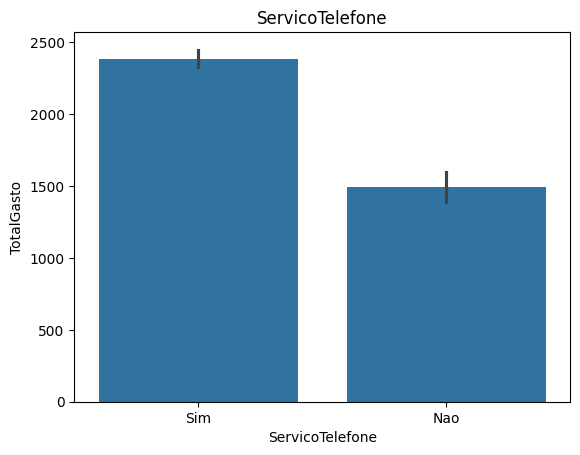




***** MultiplasLinhas *****




,MultiplasLinhas,Fca,FcaAda,Fca_%,FcaAda_%
0,Nao,2842,2842,47.572816,47.572816
1,Sim,2544,5386,42.584533,90.157349
2,SemTelefone,588,5974,9.842651,100.0


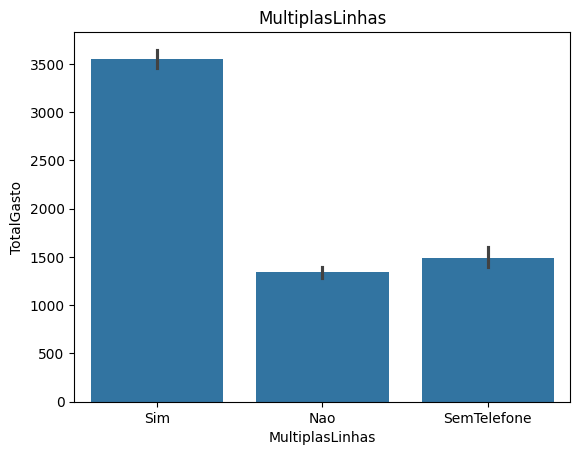




***** ServicoInternet *****




,ServicoInternet,Fca,FcaAda,Fca_%,FcaAda_%
0,Fibra,2627,2627,43.973887,43.973887
1,DSL,2063,4690,34.532976,78.506863
2,Nao,1284,5974,21.493137,100.0


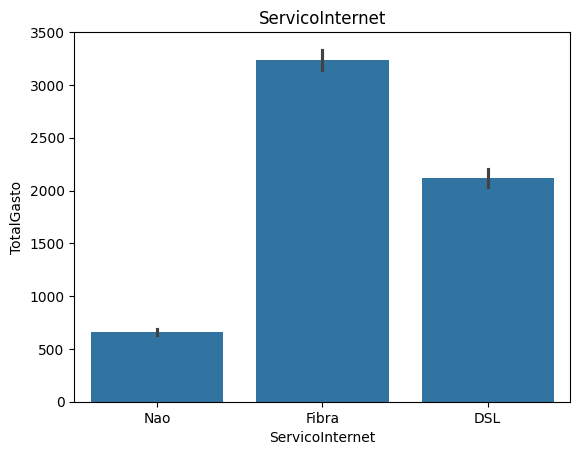




***** ServicoSegurancaOnline *****




,ServicoSegurancaOnline,Fca,FcaAda,Fca_%,FcaAda_%
0,Nao,2982,2982,49.916304,49.916304
1,Sim,1708,4690,28.590559,78.506863
2,SemInternet,1284,5974,21.493137,100.0


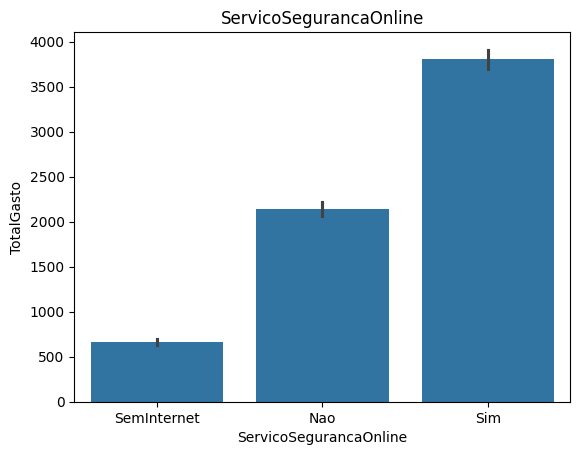




***** ServicoBackupOnline *****




,ServicoBackupOnline,Fca,FcaAda,Fca_%,FcaAda_%
0,Nao,2604,2604,43.588885,43.588885
1,Sim,2086,4690,34.917978,78.506863
2,SemInternet,1284,5974,21.493137,100.0


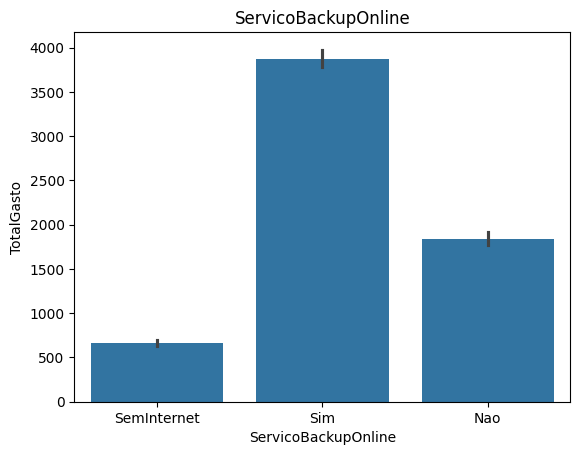




***** ProtecaoEquipamento *****




,ProtecaoEquipamento,Fca,FcaAda,Fca_%,FcaAda_%
0,Nao,2639,2639,44.174757,44.174757
1,Sim,2051,4690,34.332106,78.506863
2,SemInternet,1284,5974,21.493137,100.0


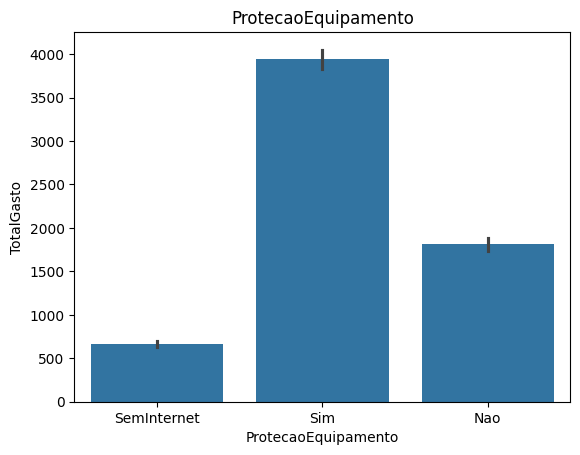




***** ServicoSuporteTecnico *****




,ServicoSuporteTecnico,Fca,FcaAda,Fca_%,FcaAda_%
0,Nao,2959,2959,49.531302,49.531302
1,Sim,1731,4690,28.975561,78.506863
2,SemInternet,1284,5974,21.493137,100.0


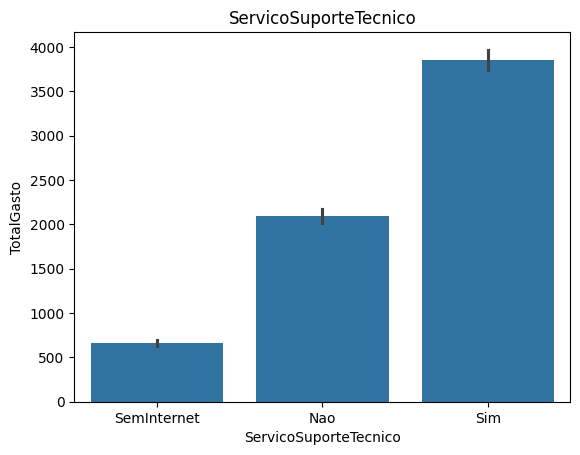




***** ServicoStreamingTV *****




,ServicoStreamingTV,Fca,FcaAda,Fca_%,FcaAda_%
0,Nao,2388,2388,39.973217,39.973217
1,Sim,2302,4690,38.533646,78.506863
2,SemInternet,1284,5974,21.493137,100.0


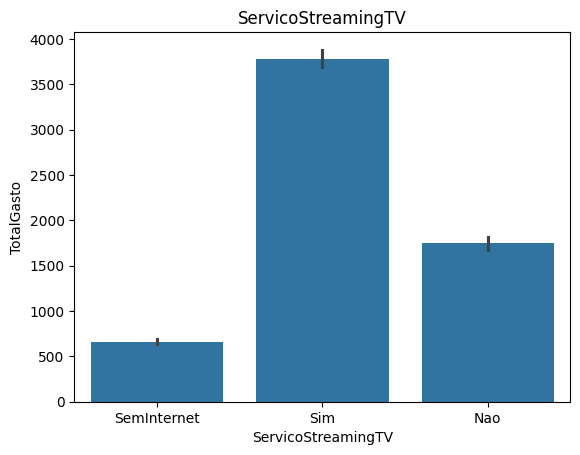




***** ServicoFilmes *****




,ServicoFilmes,Fca,FcaAda,Fca_%,FcaAda_%
0,Nao,2353,2353,39.387345,39.387345
1,Sim,2337,4690,39.119518,78.506863
2,SemInternet,1284,5974,21.493137,100.0


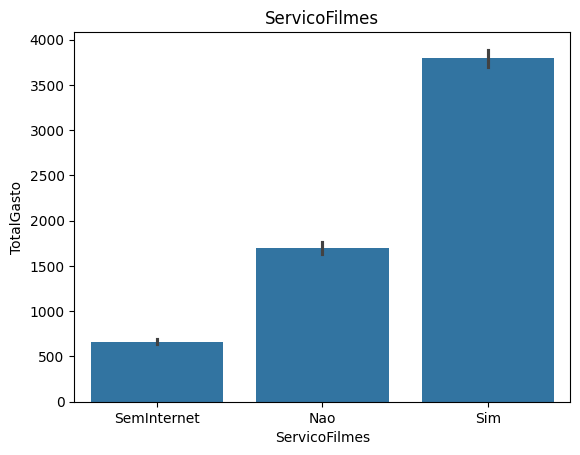




***** TipoContrato *****




,TipoContrato,Fca,FcaAda,Fca_%,FcaAda_%
0,Mensal,3269,3269,54.720455,54.720455
1,2 anos,1430,4699,23.937061,78.657516
2,Anual,1275,5974,21.342484,100.0


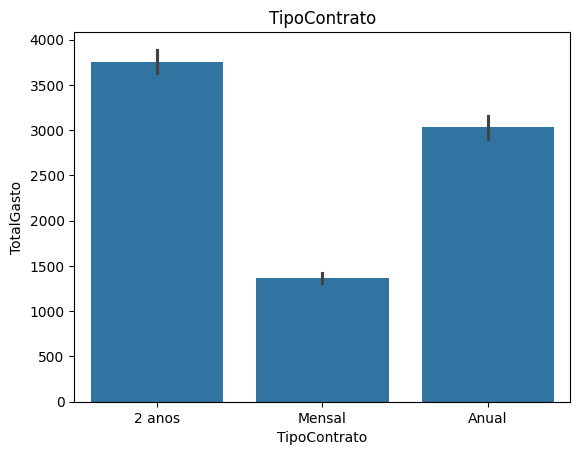




***** FaturaDigital *****




,FaturaDigital,Fca,FcaAda,Fca_%,FcaAda_%
0,Sim,3523,3523,58.972213,58.972213
1,Nao,2451,5974,41.027787,100.0


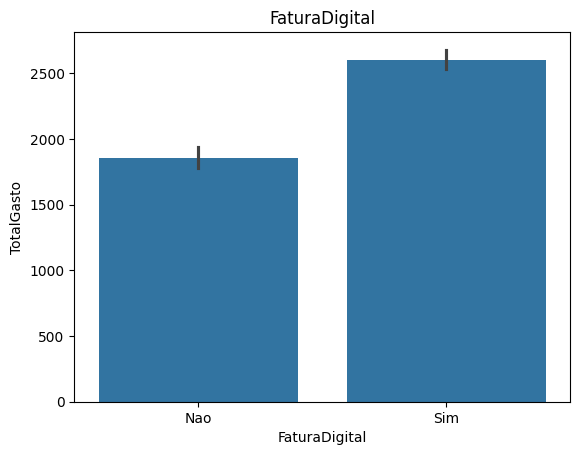




***** FormaPagamento *****




,FormaPagamento,Fca,FcaAda,Fca_%,FcaAda_%
0,BoletoEletronico,2006,2006,33.578842,33.578842
1,BoletoImpresso,1361,3367,22.782056,56.360897
2,DebitoAutomatico,1305,4672,21.84466,78.205557
3,CartaoCredito,1302,5974,21.794443,100.0


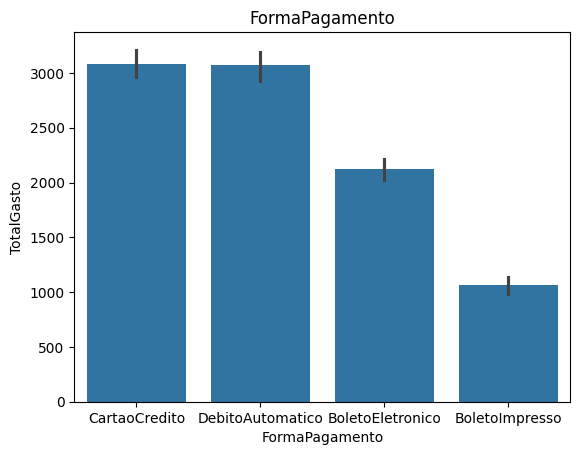




***** Churn *****




,Churn,Fca,FcaAda,Fca_%,FcaAda_%
0,Nao,4387,4387,73.434884,73.434884
1,Sim,1587,5974,26.565116,100.0


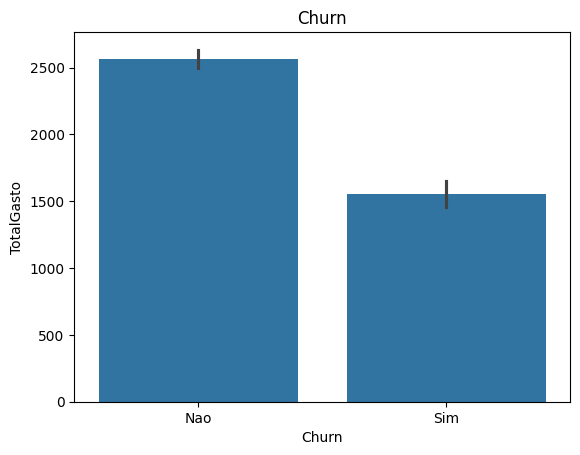

In [ ]:
for col in dff.columns:
  if col not in ['IDCliente', 'MesesComoCliente', 'ValorMensal', 'TotalGasto']:
    print('\n\n')
    print(f'***** {col} *****')
    print('\n')
    fp = dff[col].value_counts().reset_index()
    fp.columns = [col, 'Fca']
    fp['FcaAda'] = fp['Fca'].cumsum()
    fp['Fca_%'] = fp['Fca'] / fp['Fca'].sum() * 100
    fp['FcaAda_%'] = fp['FcaAda'] / fp['Fca'].sum() * 100
    display(fp)
    sns.barplot(data=dff, x=col, y='TotalGasto')
    plt.title(col)
    plt.show()